In [1]:
import glob
import pandas as pd # type: ignore
import os
import numpy as np # type: ignore
import os
import glob
import shutil
import numpy as np # type: ignore
from collections import defaultdict, deque
import matplotlib.pyplot as plt # type: ignore
from utils import box_iou, nms, xywh2xyxy

In [2]:
def read_file(pred_file):

    if os.path.isfile(pred_file) and os.path.getsize(pred_file) > 0:
        with open(pred_file, "r") as f:
            pred_boxes = [line.strip().split(" ")[1:] for line in f.readlines()]
            pred_boxes = np.array(pred_boxes).astype('float64')
            for i in range(len(pred_boxes)):
                pred_boxes[i,:-1] = xywh2xyxy(pred_boxes[i,:-1])

        return pred_boxes.astype("float")

    else:
        return np.zeros((0, 5), dtype=np.float64)

In [3]:
sources = glob.glob("alertapi_export_by_type/**/*")
len(sources)

367

In [4]:
label_folder = "sdis77_pred"

## Old code and tests

In [5]:
# settings
DEST_ROOT = "AA_output"          # where duplicated folders will be created
N_FRAMES = 6                    # number of frames to sample per sequence for scoring
SELECT_MODE = "spread"           # "spread" or "first"
SCORE_FORMAT = "{:.3f}"          # how the median is rendered in the folder name

os.makedirs(DEST_ROOT, exist_ok=True)

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff")
nb_consecutive_frames = 6
conf_thresh = 0.15
conf_th = conf_thresh * nb_consecutive_frames

In [6]:
def get_conf(last_preds):
    conf = 0
    boxes = np.zeros((0, 5), dtype=np.float64)

    # Concatenate predictions from all recent frames into a single array
    for box in last_preds:
        if box.shape[0] > 0:
            boxes = np.concatenate([boxes, box])

    if boxes.shape[0]:
        # Apply Non-Maximum Suppression (NMS) to reduce duplicate detections
        best_boxes = nms(boxes)

        # Keep detections above the confidence threshold
        detections = boxes[boxes[:, -1] > conf_thresh, :]

        # Compute IoU between best boxes and detections
        # Retain only boxes that appear in at least half of the consecutive frames
        ious_detections = box_iou(best_boxes[:, :4], detections[:, :4])
        strong_detection = np.sum(ious_detections > 0, axis=0) >= int(nb_consecutive_frames / 2)
        best_boxes = best_boxes[strong_detection, :]
        
        if best_boxes.shape[0]:
            # Compute IoU between selected best boxes and all predictions
            ious = box_iou(best_boxes[:, :4], boxes[:, :4])

            # Collect confidence scores of all overlapping detections
            best_boxes_scores = np.array([boxes[iou > 0, 4] for iou in ious[:,:1].T])

            # Pad with zeros if fewer frames than expected to ensure consistent shape
            if best_boxes_scores.shape[1] < nb_consecutive_frames:
                pad_len = nb_consecutive_frames - best_boxes_scores.shape[1]
                best_boxes_scores = np.hstack([
                    best_boxes_scores,
                    np.zeros((1, pad_len))
                ])

            # Final confidence is the median across consecutive frames
            conf = np.median(best_boxes_scores)

    return conf


In [7]:
def list_images(folder):
    return sorted([p for p in glob.glob(os.path.join(folder, "*")) if os.path.splitext(p)[1].lower() in IMG_EXTS])

def ensure_unique_path(path_without_suffix):
    """If path exists, append _2, _3, etc."""
    dest_path = path_without_suffix
    if os.path.exists(dest_path):
        i = 2
        candidate = f"{dest_path}_{i}"
        while os.path.exists(candidate):
            i += 1
            candidate = f"{dest_path}_{i}"
        dest_path = candidate
    return dest_path

def copy_images(src_folder, dst_folder):
    os.makedirs(dst_folder, exist_ok=True)
    for img in list_images(src_folder):
        shutil.copy2(img, os.path.join(dst_folder, os.path.basename(img)))

def copy_sequence(source, seq_type, name, label_folder, prefix):
    """Copies a sequence into AA_output/{prefix}_{type}_{name}/ with subfolders images and predictions."""
    prefixed_name = f"{prefix}_{seq_type}_{name}"
    dest_path = ensure_unique_path(os.path.join(DEST_ROOT, prefixed_name))

    # create subfolders
    images_dst = os.path.join(dest_path, "images")
    predictions_dst = os.path.join(dest_path, "predictions")
    os.makedirs(dest_path, exist_ok=True)

    # copy all images from source sequence into images
    copy_images(source, images_dst)

    # copy all images from the predictions source into predictions
    pred_root_for_seq = f"{label_folder}/{seq_type}_{name}/"
    if os.path.exists(pred_root_for_seq):
        copy_images(pred_root_for_seq, predictions_dst)
    else:
        os.makedirs(predictions_dst, exist_ok=True)

    return dest_path

In [8]:
# Remove destination root directory if it already exists
if os.path.isdir(DEST_ROOT):
    shutil.rmtree(DEST_ROOT)

# Iterate over confidence thresholds from 1.0 to 1.9 (step = 0.1)
for threshold_step in range(10):
    threshold = threshold_step / 10
    print("threshold :", threshold)

    false_negatives, false_positives = 0, 0

    # Iterate through all source sequences
    for sequence_path in sources:
        seq_type = os.path.basename(os.path.dirname(sequence_path))
        sequence_name = os.path.basename(sequence_path)

        # Prediction labels are stored in a parallel folder
        pred_folder = f"{label_folder}/{seq_type}_{sequence_name}/labels/"
        image_files = sorted(glob.glob(f"{sequence_path}/*"))

        raise_alerte = False
        last_preds = deque(maxlen=nb_consecutive_frames)
        conf = 0

        # Process all images in the sequence
        for img_path in image_files:
            # Each image has an associated prediction file
            pred_file = os.path.join(
                pred_folder,
                os.path.basename(img_path).replace(".jpg", ".txt").replace(".jpeg", ".txt")
            )

            # Read predicted bounding boxes and scores
            pred = read_file(pred_file)

            # Add predictions to the sliding window of recent frames
            last_preds.append(pred)

            # Compute aggregated confidence across recent frames
            conf = get_conf(last_preds)

            # If confidence is above the threshold, trigger an alert and stop
            if conf > threshold:
                raise_alerte = True
                break

        # Count missed detections (false negatives) and false positives
        if seq_type == "wildfire" and not raise_alerte:
            false_negatives += 1
            # copy_sequence(sequence_path, seq_type, sequence_name, label_folder, prefix="WF")

        elif seq_type not in ["wildfire", "other", "industrial"] and not raise_alerte:
            false_positives += 1
            # copy_sequence(sequence_path, seq_type, sequence_name, label_folder, prefix="FP")

    # Report evaluation results for the current threshold
    print(f"False negatives (wildfire without alert): {false_negatives}")
    print(f"False positives: {false_positives}")
    print()


threshold : 0.0
False negatives (wildfire without alert): 3
False positives: 71

threshold : 0.1
False negatives (wildfire without alert): 3
False positives: 71

threshold : 0.2
False negatives (wildfire without alert): 6
False positives: 96

threshold : 0.3
False negatives (wildfire without alert): 12
False positives: 126

threshold : 0.4
False negatives (wildfire without alert): 19
False positives: 144

threshold : 0.5
False negatives (wildfire without alert): 31
False positives: 157

threshold : 0.6
False negatives (wildfire without alert): 44
False positives: 169

threshold : 0.7
False negatives (wildfire without alert): 60
False positives: 174

threshold : 0.8
False negatives (wildfire without alert): 71
False positives: 175

threshold : 0.9
False negatives (wildfire without alert): 75
False positives: 175



#### debug

In [3]:
# Debug function to log confidence values per sequence type
def debug_confidence_distribution(sources, label_folder, nb_consecutive_frames, sample_limit=5):
    """
    Print confidence values for a few sequences to understand their distribution.
    
    Args:
        sources: list of sequence folders
        label_folder: folder containing prediction labels
        nb_consecutive_frames: window size for confidence calculation
        sample_limit: max number of sequences to print per type
    """
    
    counts = defaultdict(int)

    for sequence_path in sources:
        seq_type = os.path.basename(os.path.dirname(sequence_path))
        if counts[seq_type] >= sample_limit:
            continue  # only a few samples per type

        sequence_name = os.path.basename(sequence_path)
        pred_folder = f"{label_folder}/{seq_type}_{sequence_name}/labels/"
        image_files = sorted(glob.glob(f"{sequence_path}/*"))

        last_preds = deque(maxlen=nb_consecutive_frames)
        conf_values = []

        for img_path in image_files:
            pred_file = os.path.join(
                pred_folder,
                os.path.basename(img_path).replace(".jpg", ".txt").replace(".jpeg", ".txt")
            )
            pred = read_file(pred_file)
            last_preds.append(pred)
            conf = get_conf(last_preds)
            conf_values.append(conf)

        print(f"Sequence type: {seq_type}, name: {sequence_name}")
        print(f"Confidence values: {conf_values}\n")
        counts[seq_type] += 1


In [20]:
debug_confidence_distribution(sources, label_folder, nb_consecutive_frames, sample_limit=3)


Sequence type: antenna, name: 12417_20250802_163842
Confidence values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence type: antenna, name: 12497_20250804_171735
Confidence values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence type: antenna, name: 12501_20250804_182123
Confidence values: [0, 0, 0, 0, 0, 0]

Sequence type: building, name: 12504_20250804_190157
Confidence values: [0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence type: building, name: 12590_20250807_040618
Confidence values: [0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence type: building, name: 12721_20250808_155040
Confidence values: [0, 0, 0, 0, 0, 0, 0]

Sequence type: high_cloud, name: 12354_20250801_044035
Confidence values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence type: high_cloud, name: 12425_20250802_195234
Confidence values: [0, 0, 0, np.float64(0.1770225), np.float64(0.348272), np.float64(0.42424649999999997), np.float64(0.5128905), np.float64(0.5495245), np.float64(0.5128905), np.float64(0

### Comparaison

In [8]:
# Thresholds à tester
thresholds = np.arange(0.0, 1.0, 0.1)

# Initialiser matrice: rows = seuils, cols = TP, FN, FP, TN
conf_matrix = np.zeros((len(thresholds), 4), dtype=int)

for i, thresh in enumerate(thresholds):
    TP = FN = FP = TN = 0

    for sequence_path in sources:
        seq_type = os.path.basename(os.path.dirname(sequence_path))
        sequence_name = os.path.basename(sequence_path)
        pred_folder = f"{label_folder}/{seq_type}_{sequence_name}/labels/"
        image_files = sorted(glob.glob(f"{sequence_path}/*"))

        # Détection d’alerte sur la séquence
        sequence_alert = False
        for img_path in image_files:
            pred_file = os.path.join(
                pred_folder,
                os.path.basename(img_path).replace(".jpg", ".txt").replace(".jpeg", ".txt")
            )
            preds = read_file(pred_file)
            conf = np.max(preds[:, 4]) if preds.shape[0] > 0 else 0.0
            if conf > thresh:
                sequence_alert = True
                break

        # Comptage FN/FP/TP/TN
        if seq_type == "wildfire":
            if sequence_alert:
                TP += 1
            else:
                FN += 1
        elif seq_type not in ["wildfire", "other", "industrial"]:
            if sequence_alert:
                FP += 1
            else:
                TN += 1

    conf_matrix[i] = [TP, FN, FP, TN]

# Afficher la matrice
print("Threshold | TP FN FP TN")
for thresh, row in zip(thresholds, conf_matrix):
    print(f"{thresh:.1f}      | {row[0]} {row[1]} {row[2]} {row[3]}")


Threshold | TP FN FP TN
0.0      | 74 1 155 20
0.1      | 74 1 144 31
0.2      | 72 3 127 48
0.3      | 71 4 118 57
0.4      | 69 6 92 83
0.5      | 64 11 60 115
0.6      | 54 21 39 136
0.7      | 40 35 16 159
0.8      | 10 65 0 175
0.9      | 0 75 0 175


In [13]:
# ANSI color codes
GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"

def sliding_window_confusion_exact(
    sources,
    label_folder,
    window_size=4,
    method="median",       # allowed: "median", "mean", "max"
    thresholds=np.arange(0.0, 1.0, 0.1),
    graph=None             # e.g. ["FP","FN"] or None
):
    """
    Compute confusion matrices using sliding window with NMS + temporal consistency,
    reproducing the exact logic of `get_conf`.

    Prints TP, FN, FP, TN for each threshold (colored).
    Optionally plots FP/FN curves with intersection estimation.

    Args:
        sources (list): list of sequence paths
        label_folder (str): path to folder containing prediction labels
        window_size (int): number of consecutive frames for sliding window
        method (str): aggregation method; allowed: "median", "mean", "max"
        thresholds (np.array): thresholds to test
        graph (list or None): list of curves to plot, e.g. ["FP","FN"]
    """
    nb_consecutive_frames = window_size
    conf_thresh = 0.15  # baseline per-frame threshold (as in get_conf)

    FP_list, FN_list = [], []

    for thresh in thresholds:
        TP = FN = FP = TN = 0

        for sequence_path in sources:
            seq_type = os.path.basename(os.path.dirname(sequence_path))
            sequence_name = os.path.basename(sequence_path)
            pred_folder = f"{label_folder}/{seq_type}_{sequence_name}/labels/"
            image_files = sorted(glob.glob(f"{sequence_path}/*"))

            last_preds = deque(maxlen=nb_consecutive_frames)
            sequence_alert = False

            for img_path in image_files:
                pred_file = os.path.join(
                    pred_folder,
                    os.path.basename(img_path).replace(".jpg", ".txt").replace(".jpeg", ".txt")
                )
                preds = read_file(pred_file)  # Nx5 array with last column = score
                last_preds.append(preds)

                # Aggregate over sliding window using get_conf logic
                boxes = np.zeros((0, 5), dtype=np.float64)
                for p in last_preds:
                    if p.shape[0] > 0:
                        boxes = np.concatenate([boxes, p])

                conf = 0.0
                if boxes.shape[0]:
                    best_boxes = nms(boxes)
                    detections = boxes[boxes[:, -1] > conf_thresh, :]
                    ious_detections = box_iou(best_boxes[:, :4], detections[:, :4])
                    strong_detection = np.sum(ious_detections > 0, axis=0) >= int(nb_consecutive_frames / 2)
                    best_boxes = best_boxes[strong_detection, :]

                    if best_boxes.shape[0]:
                        ious = box_iou(best_boxes[:, :4], boxes[:, :4])
                        best_boxes_scores = np.array([boxes[iou > 0, 4] for iou in ious[:, :1].T])
                        if best_boxes_scores.shape[1] < nb_consecutive_frames:
                            pad_len = nb_consecutive_frames - best_boxes_scores.shape[1]
                            best_boxes_scores = np.hstack([best_boxes_scores, np.zeros((1, pad_len))])

                        # Apply aggregation method
                        if method == "median":
                            conf = np.median(best_boxes_scores)
                        elif method == "mean":
                            conf = np.mean(best_boxes_scores)
                        elif method == "max":
                            conf = np.max(best_boxes_scores)
                        else:
                            raise ValueError("Method must be 'median', 'mean', or 'max'.")

                if conf > thresh:
                    sequence_alert = True
                    break

            # Count TP / FN / FP / TN by sequence
            if seq_type == "wildfire":
                if sequence_alert:
                    TP += 1
                else:
                    FN += 1
            elif seq_type not in ["wildfire", "other", "industrial"]:
                if sequence_alert:
                    FP += 1
                else:
                    TN += 1

        FP_list.append(FP)
        FN_list.append(FN)

        # Print results with ANSI colors
        print(
            f"Threshold: {thresh:.2f} | "
            f"{GREEN}TP: {TP}{RESET}, {RED}FN: {FN}{RESET}, "
            f"{RED}FP: {FP}{RESET}, {GREEN}TN: {TN}{RESET}"
        )

    # --- Plot graph if requested ---
    if graph is not None:
        fine_thresh = np.arange(thresholds[0], thresholds[-1]+0.001, 0.01)  # centième granularity
        fp_interp = np.interp(fine_thresh, thresholds, FP_list)
        fn_interp = np.interp(fine_thresh, thresholds, FN_list)

        # Intersection estimation
        diff = fp_interp - fn_interp
        idx = np.argmin(np.abs(diff))
        inter_thresh = fine_thresh[idx]
        inter_count = int(round(fp_interp[idx]))

        # Plot curves
        plt.figure(figsize=(8,5))
        if "FP" in graph:
            plt.plot(fine_thresh, fp_interp, label="FP", color="red")
        if "FN" in graph:
            plt.plot(fine_thresh, fn_interp, label="FN", color="blue")
        plt.scatter(inter_thresh, inter_count, color="green", zorder=5)
        plt.text(inter_thresh, inter_count, f"({inter_thresh:.2f}, {inter_count})", color="green")

        plt.xlabel("Threshold")
        plt.ylabel("Count")
        plt.title(f"FP/FN vs Threshold | window_size={window_size}, method={method}")
        plt.grid(True)
        plt.legend()
        plt.show()

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71
Threshold: 0.20 | TP: 69, FN: 6, FP: 79, TN: 96
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126
Threshold: 0.40 | TP: 56, FN: 19, FP: 31, TN: 144
Threshold: 0.50 | TP: 44, FN: 31, FP: 18, TN: 157
Threshold: 0.60 | TP: 31, FN: 44, FP: 6, TN: 169
Threshold: 0.70 | TP: 15, FN: 60, FP: 1, TN: 174
Threshold: 0.80 | TP: 4, FN: 71, FP: 0, TN: 175
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175


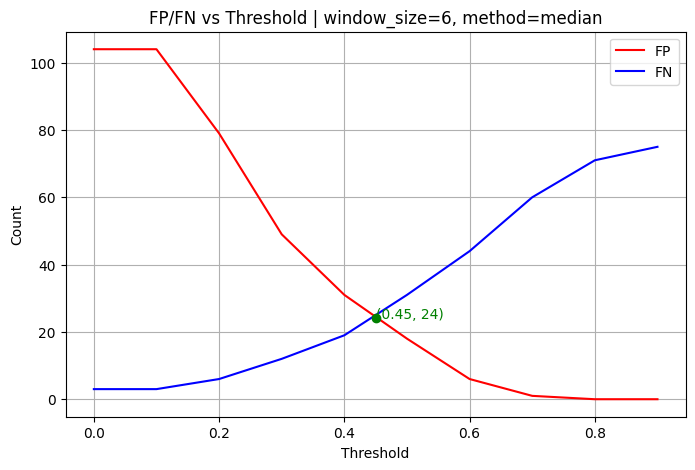

In [14]:
sliding_window_confusion_exact(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="median",
    graph=["FP","FN"]   # or None
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71
Threshold: 0.20 | TP: 71, FN: 4, FP: 82, TN: 93
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126
Threshold: 0.40 | TP: 54, FN: 21, FP: 30, TN: 145
Threshold: 0.50 | TP: 38, FN: 37, FP: 12, TN: 163
Threshold: 0.60 | TP: 26, FN: 49, FP: 4, TN: 171
Threshold: 0.70 | TP: 11, FN: 64, FP: 1, TN: 174
Threshold: 0.80 | TP: 2, FN: 73, FP: 0, TN: 175
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175


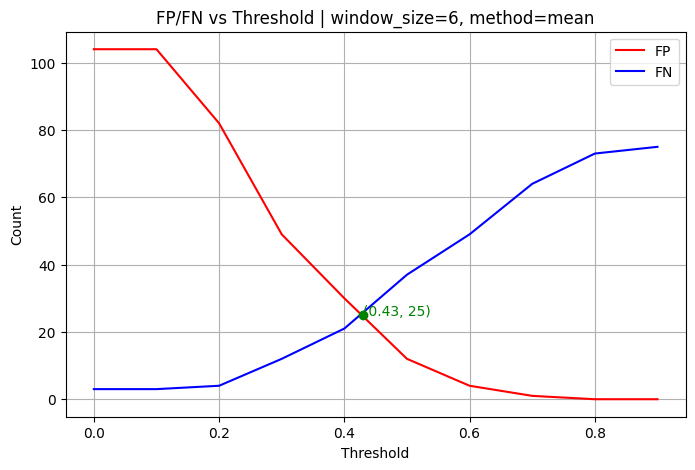

In [15]:
sliding_window_confusion_exact(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="mean",
    graph=["FP","FN"]   # or None
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71
Threshold: 0.30 | TP: 71, FN: 4, FP: 101, TN: 74
Threshold: 0.40 | TP: 69, FN: 6, FP: 80, TN: 95
Threshold: 0.50 | TP: 64, FN: 11, FP: 51, TN: 124
Threshold: 0.60 | TP: 54, FN: 21, FP: 34, TN: 141
Threshold: 0.70 | TP: 40, FN: 35, FP: 15, TN: 160
Threshold: 0.80 | TP: 10, FN: 65, FP: 0, TN: 175
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175


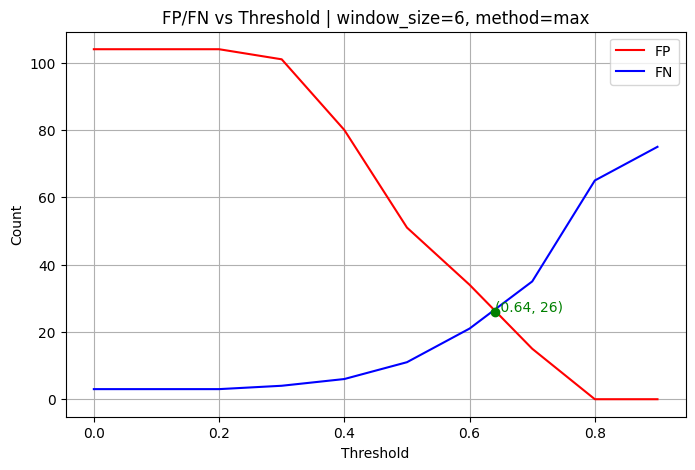

In [16]:
sliding_window_confusion_exact(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="max",
    graph=["FP","FN"]   # or None
)

## Metrics

In [5]:
def get_confs(last_preds, conf_thresh=0.15, nb_consecutive_frames=4):
    """
    Collect confidence scores from sliding window predictions, without final aggregation.

    Args:
        last_preds (deque): recent predictions, each Nx5 array with [x,y,w,h,conf]
        conf_thresh (float): minimum confidence threshold for detections
        nb_consecutive_frames (int): number of frames in sliding window

    Returns:
        np.ndarray: 1D array of confidence scores for detections in the window
    """
    boxes = np.zeros((0, 5), dtype=np.float64)

    # Concatenate predictions from all frames
    for box in last_preds:
        if box.shape[0] > 0:
            boxes = np.concatenate([boxes, box])

    if boxes.shape[0] == 0:
        return np.array([])  # no detections

    # Apply NMS to reduce duplicates
    best_boxes = nms(boxes)

    # Keep only detections above per-frame threshold
    detections = boxes[boxes[:, -1] > conf_thresh, :]

    if detections.shape[0] == 0:
        return np.array([])

    # IoU between best boxes and detections
    ious_detections = box_iou(best_boxes[:, :4], detections[:, :4])
    strong_detection = np.sum(ious_detections > 0, axis=0) >= int(nb_consecutive_frames / 2)
    best_boxes = best_boxes[strong_detection, :]

    if best_boxes.shape[0] == 0:
        return np.array([])

    # IoU with all boxes to collect scores
    ious = box_iou(best_boxes[:, :4], boxes[:, :4])
    best_boxes_scores = np.array([boxes[iou > 0, 4] for iou in ious[:, :1].T])

    # Pad with zeros if fewer detections than expected
    if best_boxes_scores.shape[1] < nb_consecutive_frames:
        pad_len = nb_consecutive_frames - best_boxes_scores.shape[1]
        best_boxes_scores = np.hstack([best_boxes_scores, np.zeros((1, pad_len))])

    # Instead of aggregating (median/mean/etc.), just return all scores
    return best_boxes_scores.flatten()


In [6]:
# ANSI color codes
GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"

In [7]:
# --- Activation functions ---
def sigmoid_scaled(x, x_min=None, x_max=None, k=10.0):
    if x_min is None: x_min = np.min(x)
    if x_max is None: x_max = np.max(x)
    x_norm = (x - x_min) / (x_max - x_min + 1e-8)
    return 1 / (1 + np.exp(-k*(x_norm - 0.5)))

def tanh_scaled(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))

def softplus(x):
    return np.log1p(np.exp(x))

def softmax(x):
    exps = np.exp(x - np.max(x))
    return exps / (np.sum(exps) + 1e-8)

In [12]:
def sliding_window_confusion_metrics(
    sources,
    label_folder,
    window_size=4,
    method="median",       # "median","mean","max","sigmoid","tanh","relu","leaky_relu","elu","softplus","softmax"
    thresholds=np.arange(0.0, 1.0, 0.1),
    graph=None,            # e.g. ["FPFN","F1","AUC"]
    k=10.0                 # only used for sigmoid
):
    """
    Compute confusion matrices with sliding window + NMS + temporal consistency.
    Prints TP, FN, FP, TN and optionally plots FP/FN, F1, AUC.
    Supports multiple activation functions for score weighting.
    """
    nb_consecutive_frames = window_size
    conf_thresh = 0.15

    FP_list, FN_list, Precision_list, Recall_list, F1_list = [], [], [], [], []

    for thresh in thresholds:
        TP = FN = FP = TN = 0

        for sequence_path in sources:
            seq_type = os.path.basename(os.path.dirname(sequence_path))
            sequence_name = os.path.basename(sequence_path)
            pred_folder = f"{label_folder}/{seq_type}_{sequence_name}/labels/"
            image_files = sorted(glob.glob(f"{sequence_path}/*"))

            last_preds = deque(maxlen=nb_consecutive_frames)
            sequence_alert = False

            for img_path in image_files:
                pred_file = os.path.join(
                    pred_folder,
                    os.path.basename(img_path).replace(".jpg", ".txt").replace(".jpeg", ".txt")
                )
                preds = read_file(pred_file)
                last_preds.append(preds)

                # Get raw detection scores
                scores = get_confs(last_preds, conf_thresh, nb_consecutive_frames)

                conf = 0.0
                if scores.size > 0:
                    if method == "median":
                        conf = np.median(scores)
                    elif method == "mean":
                        conf = np.mean(scores)
                    elif method == "max":
                        conf = np.max(scores)
                    elif method == "sigmoid":
                        s_min, s_max = scores.min(), scores.max()
                        conf = np.mean(sigmoid_scaled(scores, s_min, s_max, k=k))
                    elif method == "tanh":
                        conf = np.mean(tanh_scaled(scores))
                    elif method == "relu":
                        conf = np.mean(relu(scores))
                    elif method == "leaky_relu":
                        conf = np.mean(leaky_relu(scores))
                    elif method == "elu":
                        conf = np.mean(elu(scores))
                    elif method == "softplus":
                        conf = np.mean(softplus(scores))
                    elif method == "softmax":
                        conf = np.mean(softmax(scores))
                    else:
                        raise ValueError(f"Unknown method: {method}")

                if conf > thresh:
                    sequence_alert = True
                    break

            # Update confusion matrix
            if seq_type == "wildfire":
                if sequence_alert: TP += 1
                else: FN += 1
            elif seq_type not in ["wildfire","other","industrial"]:
                if sequence_alert: FP += 1
                else: TN += 1

        # Compute precision, recall, F1
        Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        Recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        F1 = 2 * Precision * Recall / (Precision + Recall) if (Precision + Recall) > 0 else 0

        FP_list.append(FP)
        FN_list.append(FN)
        Precision_list.append(Precision)
        Recall_list.append(Recall)
        F1_list.append(F1)

        # Print per threshold
        print(
            f"Threshold: {thresh:.2f} | "
            f"{GREEN}TP: {TP}{RESET}, {RED}FN: {FN}{RESET}, "
            f"{RED}FP: {FP}{RESET}, {GREEN}TN: {TN}{RESET} | "
            f"Precision: {Precision:.2f}, Recall: {Recall:.2f}, F1: {F1:.2f}"
        )

    # --- Plot graphs ---
    if graph is not None:
        fig, axes = plt.subplots(1, len(graph), figsize=(5*len(graph),4))
        if len(graph) == 1: axes = [axes]

        for ax, g in zip(axes, graph):
            if g=="FPFN":
                ax.plot(thresholds, FP_list, label="FP", color="red")
                ax.plot(thresholds, FN_list, label="FN", color="blue")
                ax.set_title("FP/FN vs Threshold")
            elif g == "F1":
                ax.plot(thresholds, F1_list, label="F1", color="purple", linestyle="--")
                ax.plot(thresholds, Precision_list, label="Precision", color="blue", linestyle=":")
                ax.plot(thresholds, Recall_list, label="Recall", color="red")
                ax.set_ylim([0, 1])
                ax.set_title("F1 / Precision / Recall vs Threshold")
            elif g=="AUC":
                auc = np.trapezoid(Precision_list, Recall_list)
                ax.plot(Recall_list, Precision_list, marker="o", label=f"AUC={auc:.3f}")
                ax.set_xlim([0,1])
                ax.set_ylim([0,1])
                ax.set_title("PR Curve")
            ax.grid(True)
            ax.legend()

        plt.suptitle(f"Sliding Window Metrics | window_size={window_size}, method={method}")
        plt.tight_layout()
        plt.show()

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 69, FN: 6, FP: 79, TN: 96 | Precision: 0.47, Recall: 0.92, F1: 0.62
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126 | Precision: 0.56, Recall: 0.84, F1: 0.67
Threshold: 0.40 | TP: 56, FN: 19, FP: 31, TN: 144 | Precision: 0.64, Recall: 0.75, F1: 0.69
Threshold: 0.50 | TP: 44, FN: 31, FP: 18, TN: 157 | Precision: 0.71, Recall: 0.59, F1: 0.64
Threshold: 0.60 | TP: 31, FN: 44, FP: 6, TN: 169 | Precision: 0.84, Recall: 0.41, F1: 0.55
Threshold: 0.70 | TP: 15, FN: 60, FP: 1, TN: 174 | Precision: 0.94, Recall: 0.20, F1: 0.33
Threshold: 0.80 | TP: 4, FN: 71, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.05, F1: 0.10
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


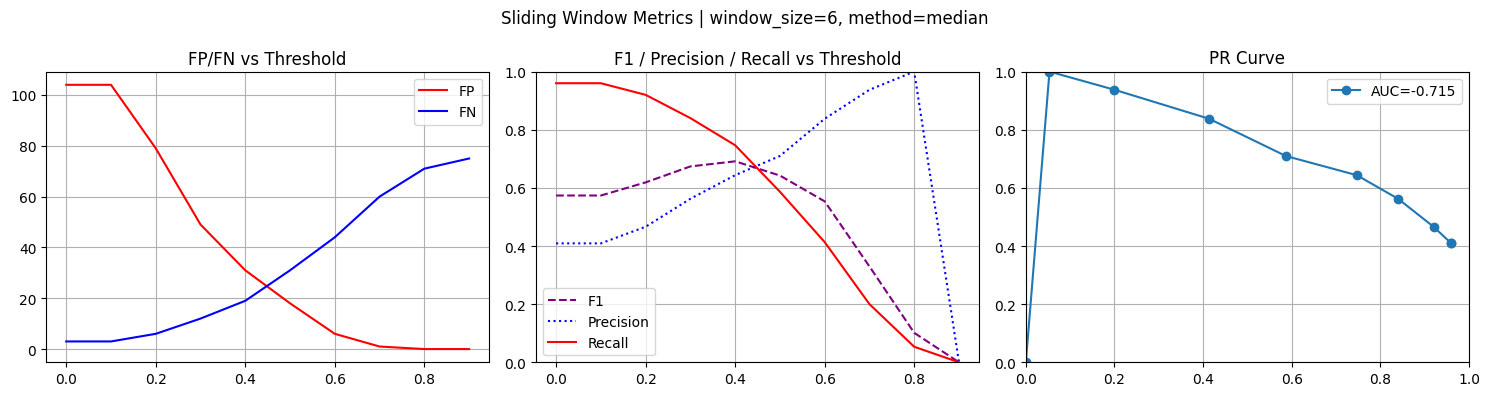

In [13]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="median",
    graph=["FPFN", "F1", "AUC"]
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 71, FN: 4, FP: 82, TN: 93 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126 | Precision: 0.56, Recall: 0.84, F1: 0.67
Threshold: 0.40 | TP: 54, FN: 21, FP: 30, TN: 145 | Precision: 0.64, Recall: 0.72, F1: 0.68
Threshold: 0.50 | TP: 38, FN: 37, FP: 12, TN: 163 | Precision: 0.76, Recall: 0.51, F1: 0.61
Threshold: 0.60 | TP: 26, FN: 49, FP: 4, TN: 171 | Precision: 0.87, Recall: 0.35, F1: 0.50
Threshold: 0.70 | TP: 11, FN: 64, FP: 1, TN: 174 | Precision: 0.92, Recall: 0.15, F1: 0.25
Threshold: 0.80 | TP: 2, FN: 73, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.03, F1: 0.05
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


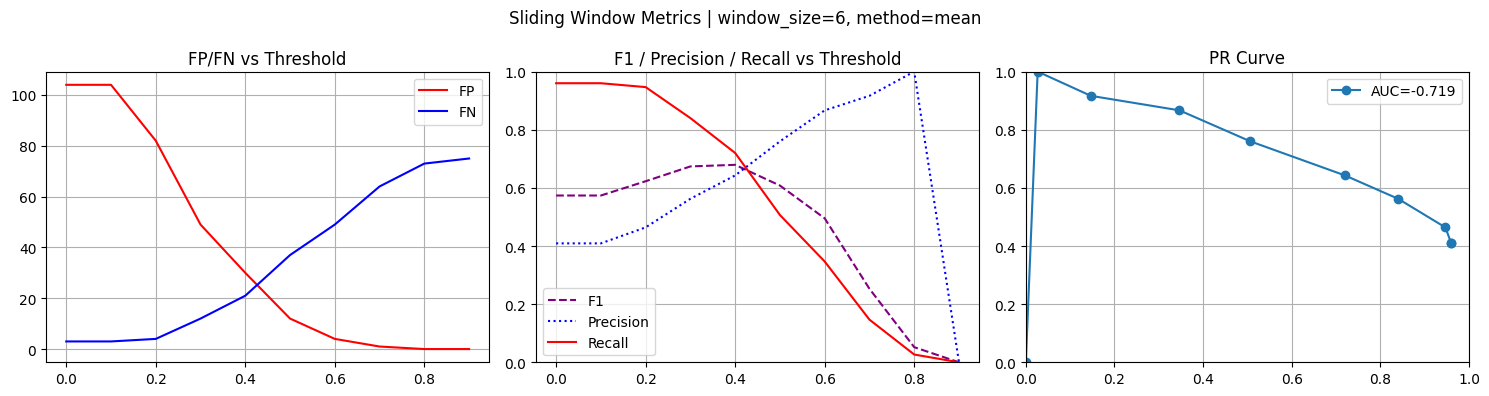

In [14]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="mean",
    graph=["FPFN", "F1", "AUC"]
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 71, FN: 4, FP: 101, TN: 74 | Precision: 0.41, Recall: 0.95, F1: 0.57
Threshold: 0.40 | TP: 69, FN: 6, FP: 80, TN: 95 | Precision: 0.46, Recall: 0.92, F1: 0.62
Threshold: 0.50 | TP: 64, FN: 11, FP: 51, TN: 124 | Precision: 0.56, Recall: 0.85, F1: 0.67
Threshold: 0.60 | TP: 54, FN: 21, FP: 34, TN: 141 | Precision: 0.61, Recall: 0.72, F1: 0.66
Threshold: 0.70 | TP: 40, FN: 35, FP: 15, TN: 160 | Precision: 0.73, Recall: 0.53, F1: 0.62
Threshold: 0.80 | TP: 10, FN: 65, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.13, F1: 0.24
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


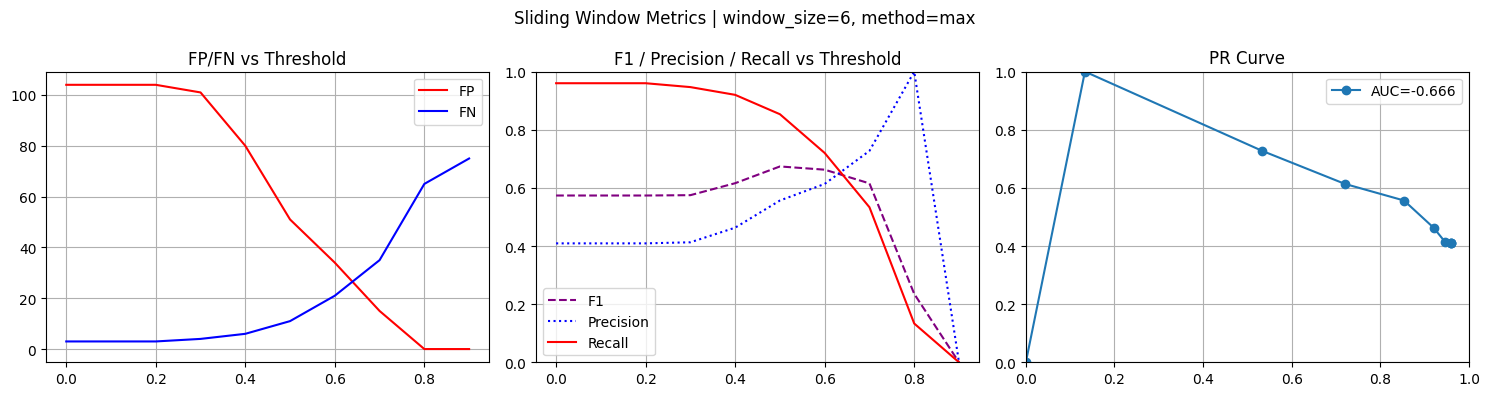

In [15]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="max",
    graph=["FPFN", "F1", "AUC"]
)

### Sigmoid

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 72, FN: 3, FP: 102, TN: 73 | Precision: 0.41, Recall: 0.96, F1: 0.58
Threshold: 0.40 | TP: 70, FN: 5, FP: 96, TN: 79 | Precision: 0.42, Recall: 0.93, F1: 0.58
Threshold: 0.50 | TP: 66, FN: 9, FP: 78, TN: 97 | Precision: 0.46, Recall: 0.88, F1: 0.60
Threshold: 0.60 | TP: 60, FN: 15, FP: 53, TN: 122 | Precision: 0.53, Recall: 0.80, F1: 0.64
Threshold: 0.70 | TP: 48, FN: 27, FP: 27, TN: 148 | Precision: 0.64, Recall: 0.64, F1: 0.64
Threshold: 0.80 | TP: 20, FN: 55, FP: 10, TN: 165 | Precision: 0.67, Recall: 0.27, F1: 0.38
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


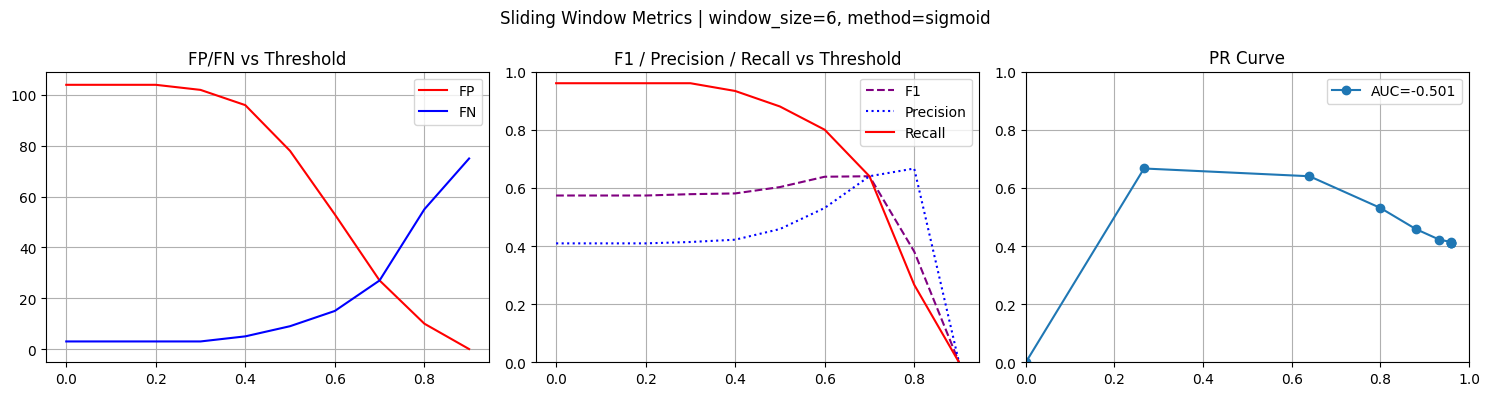

In [16]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="sigmoid",
    graph=["FPFN", "F1", "AUC"]
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 119, TN: 56 | Precision: 0.38, Recall: 0.96, F1: 0.54
Threshold: 0.10 | TP: 72, FN: 3, FP: 119, TN: 56 | Precision: 0.38, Recall: 0.96, F1: 0.54
Threshold: 0.20 | TP: 72, FN: 3, FP: 119, TN: 56 | Precision: 0.38, Recall: 0.96, F1: 0.54
Threshold: 0.30 | TP: 72, FN: 3, FP: 118, TN: 57 | Precision: 0.38, Recall: 0.96, F1: 0.54
Threshold: 0.40 | TP: 72, FN: 3, FP: 113, TN: 62 | Precision: 0.39, Recall: 0.96, F1: 0.55
Threshold: 0.50 | TP: 72, FN: 3, FP: 102, TN: 73 | Precision: 0.41, Recall: 0.96, F1: 0.58
Threshold: 0.60 | TP: 69, FN: 6, FP: 78, TN: 97 | Precision: 0.47, Recall: 0.92, F1: 0.62
Threshold: 0.70 | TP: 60, FN: 15, FP: 61, TN: 114 | Precision: 0.50, Recall: 0.80, F1: 0.61
Threshold: 0.80 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


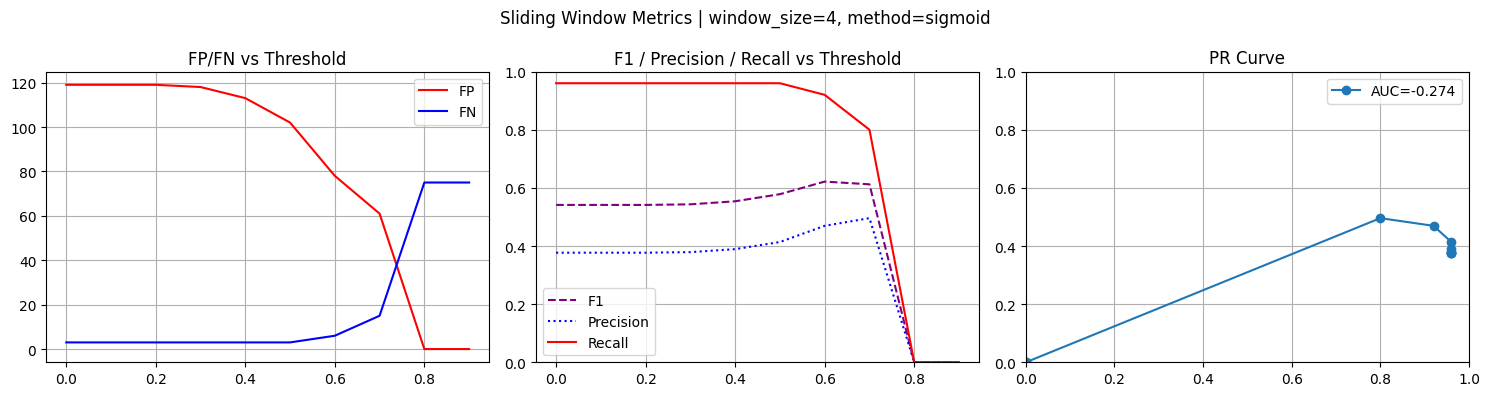

In [17]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=4,
    method="sigmoid",
    graph=["FPFN", "F1", "AUC"]
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 71, FN: 4, FP: 80, TN: 95 | Precision: 0.47, Recall: 0.95, F1: 0.63
Threshold: 0.30 | TP: 60, FN: 15, FP: 46, TN: 129 | Precision: 0.57, Recall: 0.80, F1: 0.66
Threshold: 0.40 | TP: 51, FN: 24, FP: 24, TN: 151 | Precision: 0.68, Recall: 0.68, F1: 0.68
Threshold: 0.50 | TP: 33, FN: 42, FP: 6, TN: 169 | Precision: 0.85, Recall: 0.44, F1: 0.58
Threshold: 0.60 | TP: 11, FN: 64, FP: 1, TN: 174 | Precision: 0.92, Recall: 0.15, F1: 0.25
Threshold: 0.70 | TP: 1, FN: 74, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.01, F1: 0.03
Threshold: 0.80 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


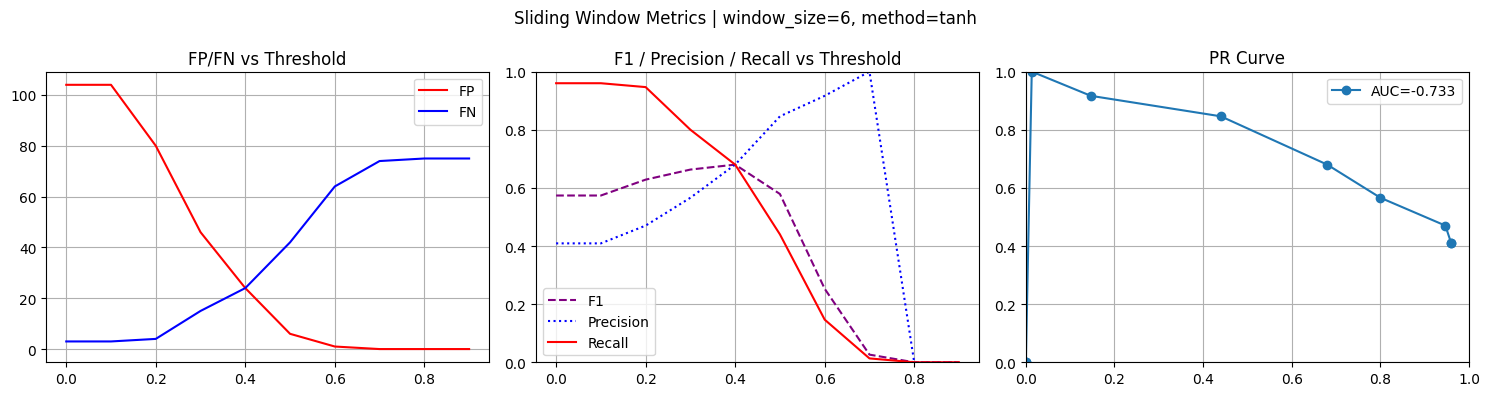

In [18]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="tanh",
    graph=["FPFN", "F1", "AUC"]
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 71, FN: 4, FP: 82, TN: 93 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126 | Precision: 0.56, Recall: 0.84, F1: 0.67
Threshold: 0.40 | TP: 54, FN: 21, FP: 30, TN: 145 | Precision: 0.64, Recall: 0.72, F1: 0.68
Threshold: 0.50 | TP: 38, FN: 37, FP: 12, TN: 163 | Precision: 0.76, Recall: 0.51, F1: 0.61
Threshold: 0.60 | TP: 26, FN: 49, FP: 4, TN: 171 | Precision: 0.87, Recall: 0.35, F1: 0.50
Threshold: 0.70 | TP: 11, FN: 64, FP: 1, TN: 174 | Precision: 0.92, Recall: 0.15, F1: 0.25
Threshold: 0.80 | TP: 2, FN: 73, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.03, F1: 0.05
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


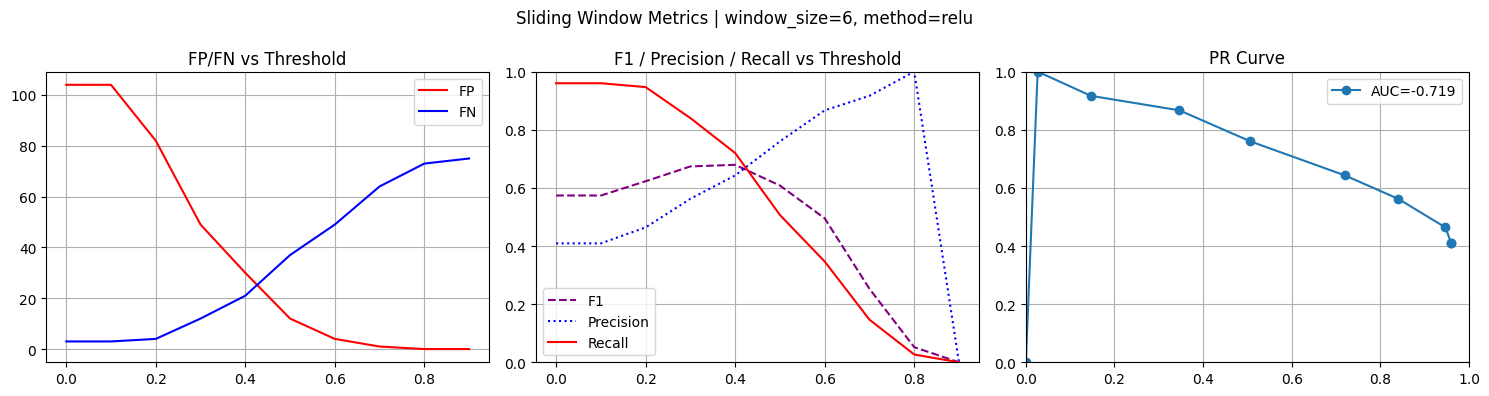

In [19]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="relu",
    graph=["FPFN", "F1", "AUC"]
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 72, FN: 3, FP: 102, TN: 73 | Precision: 0.41, Recall: 0.96, F1: 0.58
Threshold: 0.40 | TP: 70, FN: 5, FP: 95, TN: 80 | Precision: 0.42, Recall: 0.93, F1: 0.58
Threshold: 0.50 | TP: 66, FN: 9, FP: 80, TN: 95 | Precision: 0.45, Recall: 0.88, F1: 0.60
Threshold: 0.60 | TP: 61, FN: 14, FP: 55, TN: 120 | Precision: 0.53, Recall: 0.81, F1: 0.64
Threshold: 0.70 | TP: 49, FN: 26, FP: 33, TN: 142 | Precision: 0.60, Recall: 0.65, F1: 0.62
Threshold: 0.80 | TP: 27, FN: 48, FP: 18, TN: 157 | Precision: 0.60, Recall: 0.36, F1: 0.45
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


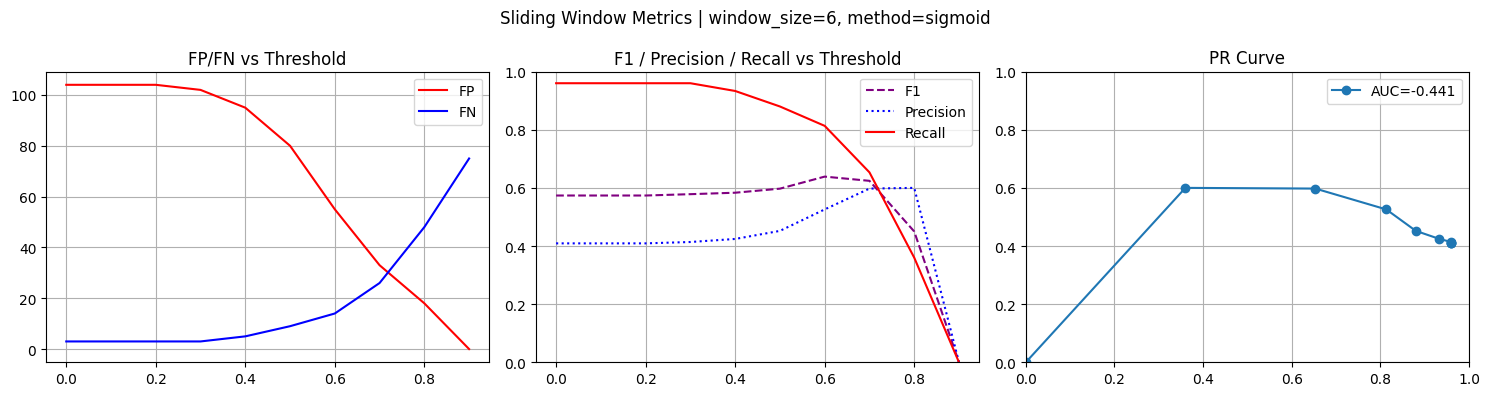

In [20]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="sigmoid",
    graph=["FPFN", "F1", "AUC"],
    k=15.0
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.40 | TP: 71, FN: 4, FP: 99, TN: 76 | Precision: 0.42, Recall: 0.95, F1: 0.58
Threshold: 0.50 | TP: 66, FN: 9, FP: 78, TN: 97 | Precision: 0.46, Recall: 0.88, F1: 0.60
Threshold: 0.60 | TP: 57, FN: 18, FP: 44, TN: 131 | Precision: 0.56, Recall: 0.76, F1: 0.65
Threshold: 0.70 | TP: 32, FN: 43, FP: 14, TN: 161 | Precision: 0.70, Recall: 0.43, F1: 0.53
Threshold: 0.80 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


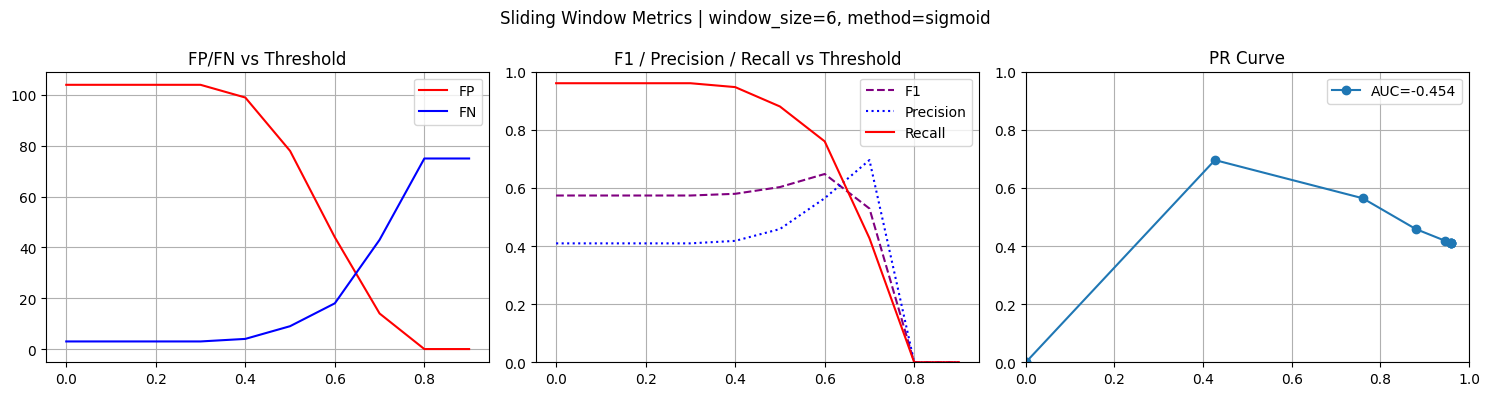

In [21]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="sigmoid",
    graph=["FPFN", "F1", "AUC"],
    k=5.0
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.40 | TP: 72, FN: 3, FP: 103, TN: 72 | Precision: 0.41, Recall: 0.96, F1: 0.58
Threshold: 0.50 | TP: 66, FN: 9, FP: 76, TN: 99 | Precision: 0.46, Recall: 0.88, F1: 0.61
Threshold: 0.60 | TP: 47, FN: 28, FP: 29, TN: 146 | Precision: 0.62, Recall: 0.63, F1: 0.62
Threshold: 0.70 | TP: 1, FN: 74, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.01, F1: 0.03
Threshold: 0.80 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


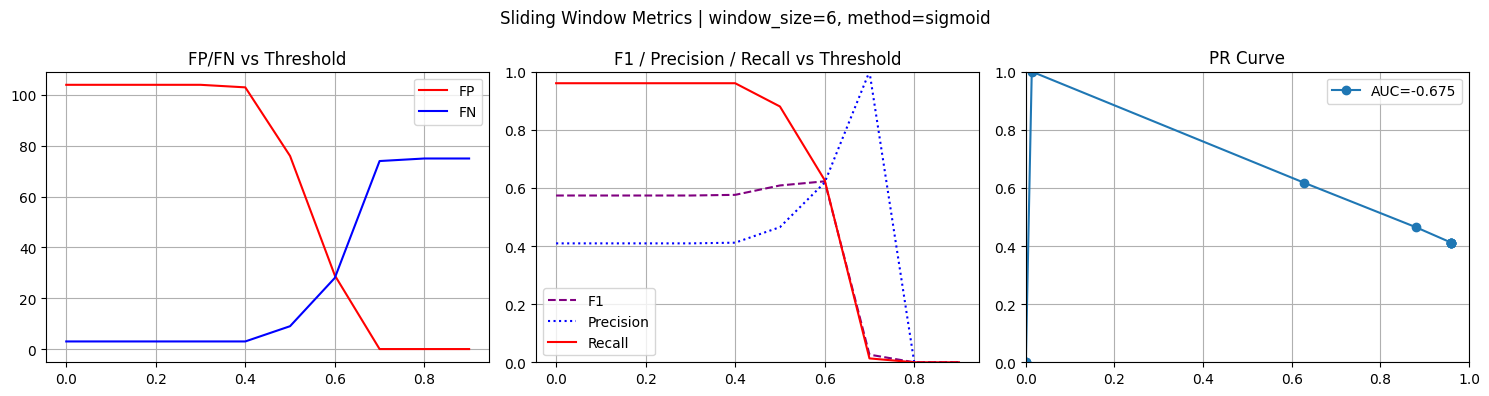

In [22]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="sigmoid",
    graph=["FPFN", "F1", "AUC"],
    k=3.0
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 103, TN: 72 | Precision: 0.41, Recall: 0.96, F1: 0.58
Threshold: 0.30 | TP: 72, FN: 3, FP: 102, TN: 73 | Precision: 0.41, Recall: 0.96, F1: 0.58
Threshold: 0.40 | TP: 69, FN: 6, FP: 94, TN: 81 | Precision: 0.42, Recall: 0.92, F1: 0.58
Threshold: 0.50 | TP: 66, FN: 9, FP: 79, TN: 96 | Precision: 0.46, Recall: 0.88, F1: 0.60
Threshold: 0.60 | TP: 61, FN: 14, FP: 57, TN: 118 | Precision: 0.52, Recall: 0.81, F1: 0.63
Threshold: 0.70 | TP: 49, FN: 26, FP: 34, TN: 141 | Precision: 0.59, Recall: 0.65, F1: 0.62
Threshold: 0.80 | TP: 40, FN: 35, FP: 22, TN: 153 | Precision: 0.65, Recall: 0.53, F1: 0.58
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


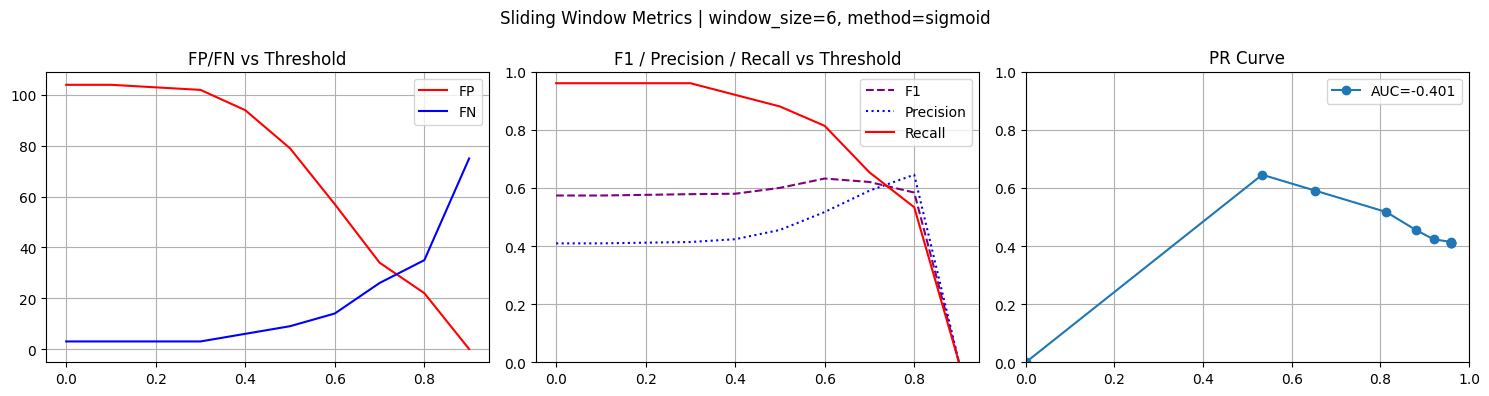

In [23]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="sigmoid",
    graph=["FPFN", "F1", "AUC"],
    k=25
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 71, FN: 4, FP: 82, TN: 93 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126 | Precision: 0.56, Recall: 0.84, F1: 0.67
Threshold: 0.40 | TP: 54, FN: 21, FP: 30, TN: 145 | Precision: 0.64, Recall: 0.72, F1: 0.68
Threshold: 0.50 | TP: 38, FN: 37, FP: 12, TN: 163 | Precision: 0.76, Recall: 0.51, F1: 0.61
Threshold: 0.60 | TP: 26, FN: 49, FP: 4, TN: 171 | Precision: 0.87, Recall: 0.35, F1: 0.50
Threshold: 0.70 | TP: 11, FN: 64, FP: 1, TN: 174 | Precision: 0.92, Recall: 0.15, F1: 0.25
Threshold: 0.80 | TP: 2, FN: 73, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.03, F1: 0.05
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


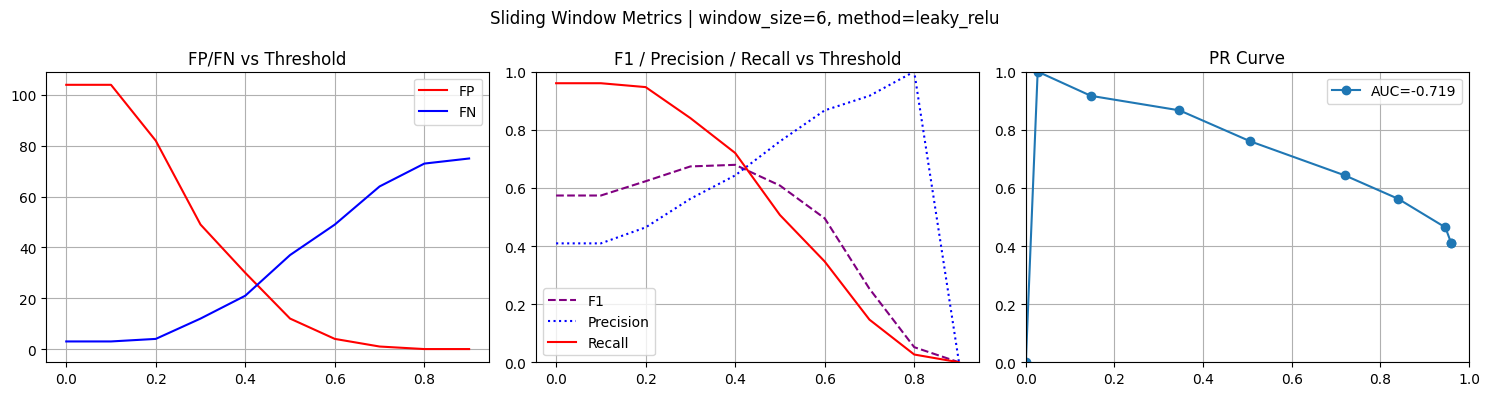

In [24]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="leaky_relu",
    graph=["FPFN", "F1", "AUC"],
    k=10
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 71, FN: 4, FP: 82, TN: 93 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126 | Precision: 0.56, Recall: 0.84, F1: 0.67
Threshold: 0.40 | TP: 54, FN: 21, FP: 30, TN: 145 | Precision: 0.64, Recall: 0.72, F1: 0.68
Threshold: 0.50 | TP: 38, FN: 37, FP: 12, TN: 163 | Precision: 0.76, Recall: 0.51, F1: 0.61
Threshold: 0.60 | TP: 26, FN: 49, FP: 4, TN: 171 | Precision: 0.87, Recall: 0.35, F1: 0.50
Threshold: 0.70 | TP: 11, FN: 64, FP: 1, TN: 174 | Precision: 0.92, Recall: 0.15, F1: 0.25
Threshold: 0.80 | TP: 2, FN: 73, FP: 0, TN: 175 | Precision: 1.00, Recall: 0.03, F1: 0.05
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


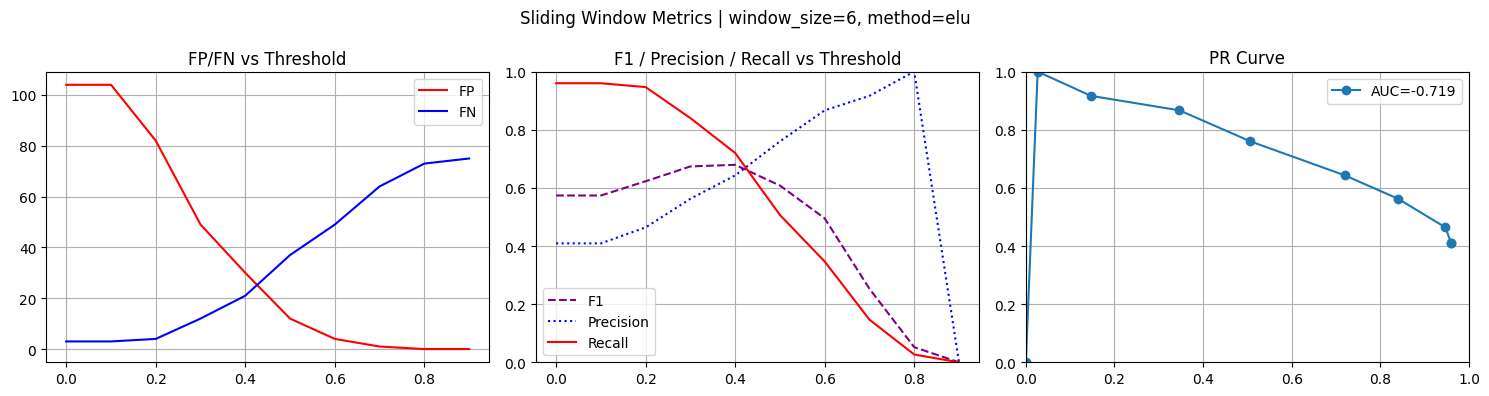

In [25]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="elu",
    graph=["FPFN", "F1", "AUC"],
    k=10
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.40 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.50 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.60 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.70 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.80 | TP: 71, FN: 4, FP: 83, TN: 92 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.90 | TP: 56, FN: 19, FP: 31, TN: 144 | Precision: 0.64, Recall: 0.75, F1: 0.69


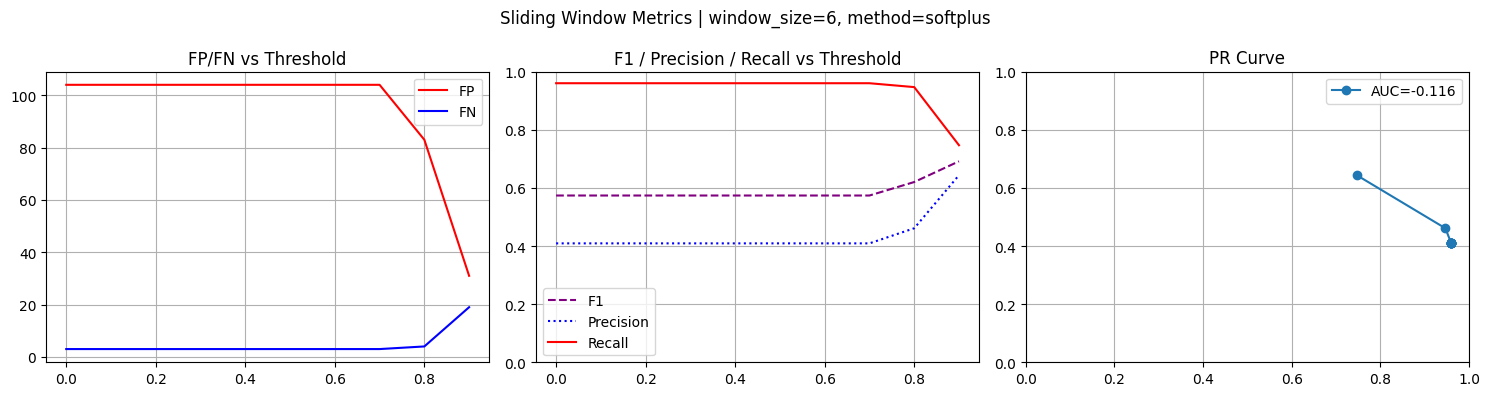

In [26]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="softplus",
    graph=["FPFN", "F1", "AUC"],
    k=10
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.30 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.40 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.50 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.60 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.70 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.80 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00
Threshold: 0.90 | TP: 0, FN: 75, FP: 0, TN: 175 | Precision: 0.00, Recall: 0.00, F1: 0.00


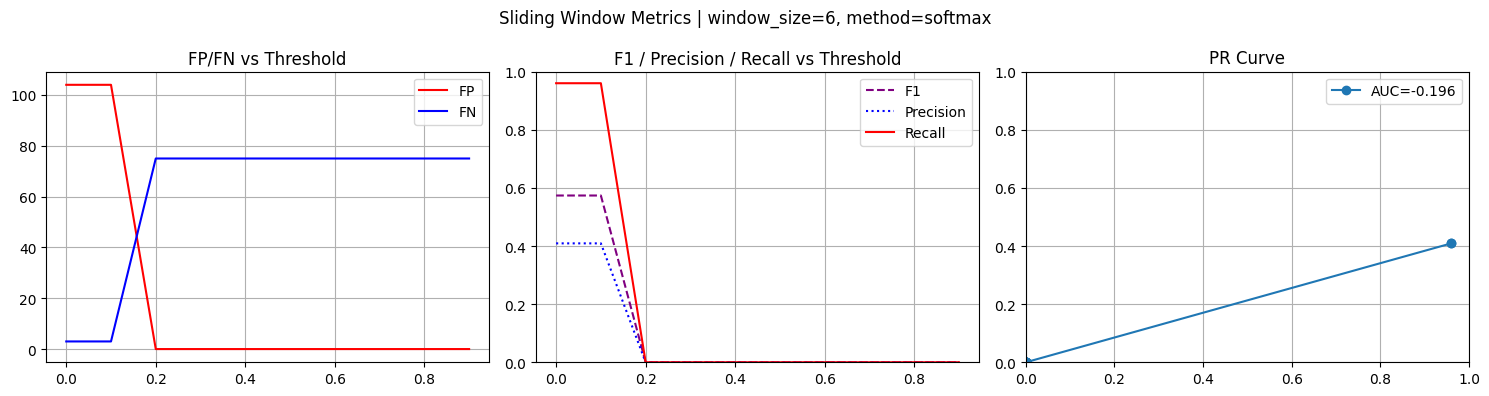

In [27]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="softmax",
    graph=["FPFN", "F1", "AUC"],
    k=10
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.40 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.50 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.60 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.70 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.80 | TP: 71, FN: 4, FP: 83, TN: 92 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.90 | TP: 56, FN: 19, FP: 31, TN: 144 | Precision: 0.64, Recall: 0.75, F1: 0.69


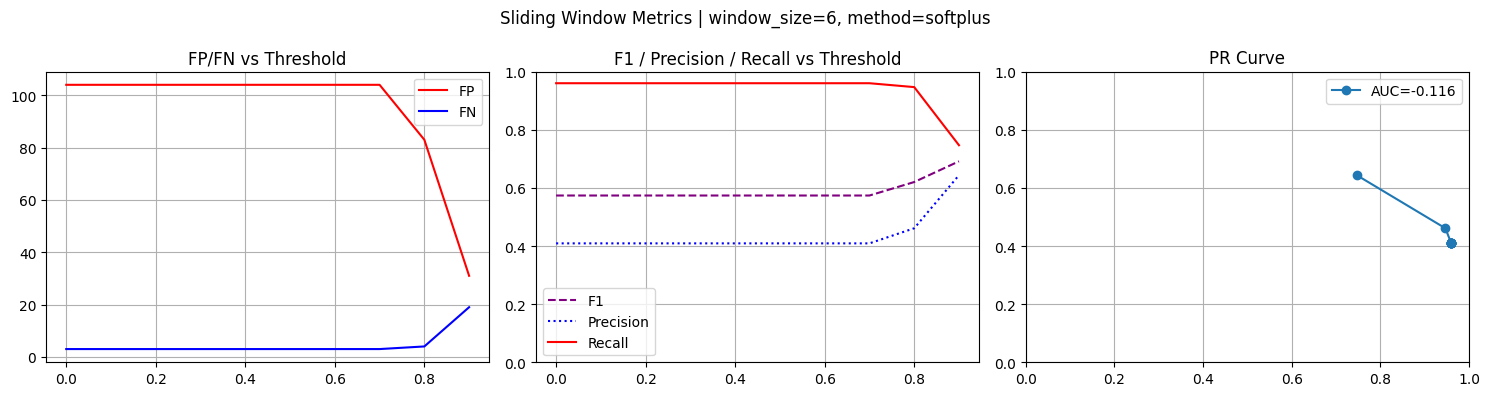

In [28]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="softplus",
    graph=["FPFN", "F1", "AUC"],
    k=20
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.20 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.30 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.40 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.50 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.60 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.70 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.80 | TP: 71, FN: 4, FP: 83, TN: 92 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.90 | TP: 56, FN: 19, FP: 31, TN: 144 | Precision: 0.64, Recall: 0.75, F1: 0.69


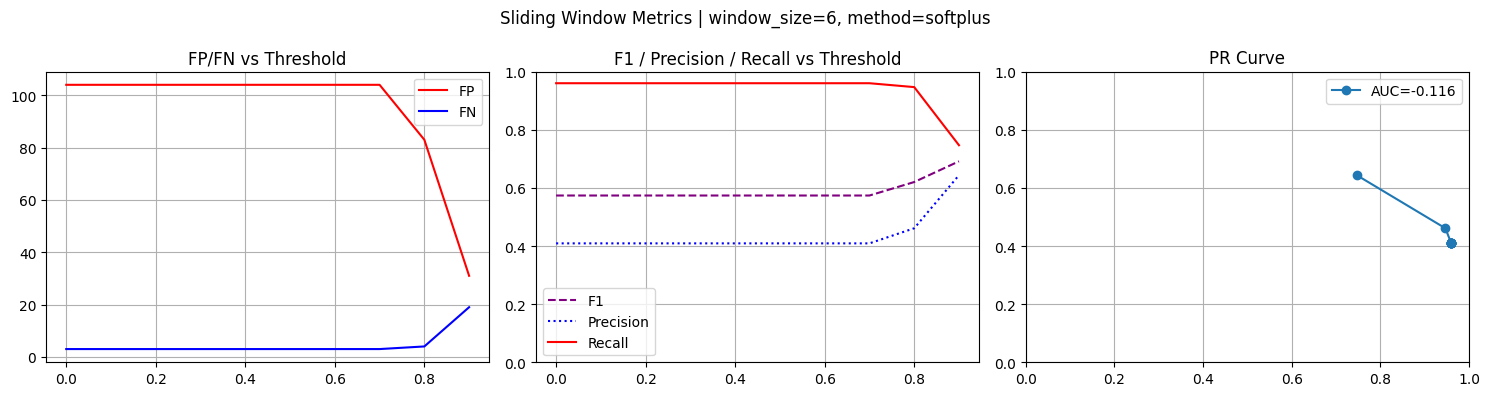

In [29]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="softplus",
    graph=["FPFN", "F1", "AUC"],
    k=5
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.05 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.15 | TP: 71, FN: 4, FP: 95, TN: 80 | Precision: 0.43, Recall: 0.95, F1: 0.59
Threshold: 0.20 | TP: 69, FN: 6, FP: 79, TN: 96 | Precision: 0.47, Recall: 0.92, F1: 0.62
Threshold: 0.25 | TP: 66, FN: 9, FP: 63, TN: 112 | Precision: 0.51, Recall: 0.88, F1: 0.65
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126 | Precision: 0.56, Recall: 0.84, F1: 0.67
Threshold: 0.35 | TP: 59, FN: 16, FP: 40, TN: 135 | Precision: 0.60, Recall: 0.79, F1: 0.68
Threshold: 0.40 | TP: 56, FN: 19, FP: 31, TN: 144 | Precision: 0.64, Recall: 0.75, F1: 0.69
Threshold: 0.45 | TP: 51, FN: 24, FP: 29, TN: 146 | Precision: 0.64, Recall: 0.68, F1: 0.66
Threshold: 0.50 | TP: 44, FN: 31, FP: 18, TN: 157 | Precision: 0.71, Recall: 0.59, F1: 0

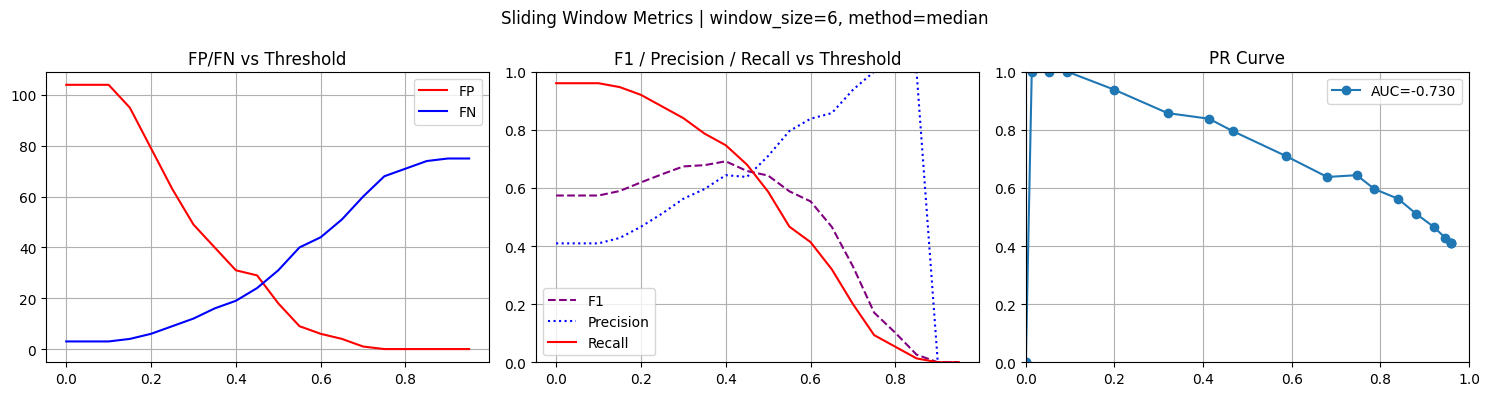

In [30]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="median",
    graph=["FPFN", "F1", "AUC"],
    thresholds=np.arange(0.0, 1.0, 0.05)
)

Threshold: 0.00 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.05 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.10 | TP: 72, FN: 3, FP: 104, TN: 71 | Precision: 0.41, Recall: 0.96, F1: 0.57
Threshold: 0.15 | TP: 72, FN: 3, FP: 102, TN: 73 | Precision: 0.41, Recall: 0.96, F1: 0.58
Threshold: 0.20 | TP: 71, FN: 4, FP: 82, TN: 93 | Precision: 0.46, Recall: 0.95, F1: 0.62
Threshold: 0.25 | TP: 69, FN: 6, FP: 63, TN: 112 | Precision: 0.52, Recall: 0.92, F1: 0.67
Threshold: 0.30 | TP: 63, FN: 12, FP: 49, TN: 126 | Precision: 0.56, Recall: 0.84, F1: 0.67
Threshold: 0.35 | TP: 60, FN: 15, FP: 37, TN: 138 | Precision: 0.62, Recall: 0.80, F1: 0.70
Threshold: 0.40 | TP: 54, FN: 21, FP: 30, TN: 145 | Precision: 0.64, Recall: 0.72, F1: 0.68
Threshold: 0.45 | TP: 47, FN: 28, FP: 19, TN: 156 | Precision: 0.71, Recall: 0.63, F1: 0.67
Threshold: 0.50 | TP: 38, FN: 37, FP: 12, TN: 163 | Precision: 0.76, Recall: 0.51, F1: 

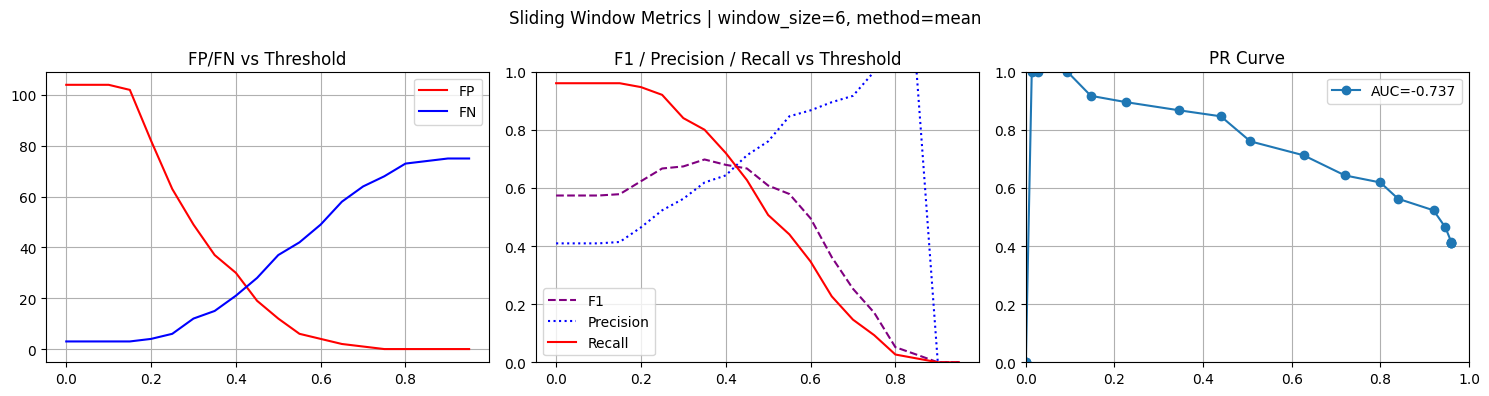

In [31]:
sliding_window_confusion_metrics(
    sources=sources,
    label_folder=label_folder,
    window_size=6,
    method="mean",
    graph=["FPFN", "F1", "AUC"],
    thresholds=np.arange(0.0, 1.0, 0.05)
)

### Debug sequences

In [42]:
def debug_sequence_confidences(
    sources,
    label_folder,
    window_size=6
):
    """
    Debug function to print raw detection scores (frame by frame) for each sequence.
    No thresholding, shows all confidence values returned by get_confs.

    Args:
        sources (list): list of sequence paths
        label_folder (str): folder containing prediction labels
        window_size (int): number of consecutive frames for sliding window
    """
    nb_consecutive_frames = window_size

    for sequence_path in sources:
        seq_type = os.path.basename(os.path.dirname(sequence_path))
        sequence_name = os.path.basename(sequence_path)
        pred_folder = f"{label_folder}/{seq_type}_{sequence_name}/labels/"
        image_files = sorted(glob.glob(f"{sequence_path}/*"))

        last_preds = deque(maxlen=nb_consecutive_frames)

        print(f"\n=== Sequence: {sequence_name} | Type: {seq_type} ===")

        for frame_idx, img_path in enumerate(image_files):
            pred_file = os.path.join(
                pred_folder,
                os.path.basename(img_path).replace(".jpg", ".txt").replace(".jpeg", ".txt")
            )
            preds = read_file(pred_file)
            last_preds.append(preds)

            # Collect raw scores from get_confs (without thresholding)
            scores = get_confs(last_preds, conf_thresh=0.0, nb_consecutive_frames=nb_consecutive_frames)

            if scores.size > 0:
                for det_idx, s in enumerate(scores):
                    print(f"Frame {frame_idx:03d} | Detection {det_idx+1} | Score={s:.3f}")
            else:
                print(f"Frame {frame_idx:03d} | No detection")


In [43]:
debug_sequence_confidences(
    sources = sources,
    label_folder = label_folder,
    window_size=6
)



=== Sequence: 12417_20250802_163842 | Type: antenna ===
Frame 000 | No detection
Frame 001 | No detection
Frame 002 | No detection
Frame 003 | No detection
Frame 004 | No detection
Frame 005 | No detection
Frame 006 | No detection
Frame 007 | No detection
Frame 008 | No detection
Frame 009 | No detection
Frame 010 | No detection
Frame 011 | No detection
Frame 012 | No detection
Frame 013 | No detection
Frame 014 | No detection
Frame 015 | No detection

=== Sequence: 12497_20250804_171735 | Type: antenna ===
Frame 000 | No detection
Frame 001 | No detection
Frame 002 | No detection
Frame 003 | No detection
Frame 004 | No detection
Frame 005 | No detection
Frame 006 | No detection
Frame 007 | No detection
Frame 008 | No detection
Frame 009 | No detection
Frame 010 | No detection
Frame 011 | No detection
Frame 012 | No detection
Frame 013 | No detection
Frame 014 | No detection
Frame 015 | No detection
Frame 016 | No detection
Frame 017 | No detection
Frame 018 | No detection
Frame 019 |